
---

# **`SVD In Python`**

---


### **Import Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import warnings
warnings.filterwarnings("ignore")

### **Load Titanic Dataset**

In [2]:
titanic_df = sns.load_dataset('titanic') # load dataset in csv format

In [3]:
# check columns names
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

### **Preprocess the Data**


In [4]:
# selecting features for SVD
features = ['pclass','sex','age','fare','survived']

# pipeline for numerical features
numeric_features = ['age','fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# pipeline for categorical features
categorical_features = ['pclass','sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # this is to fill missing values with 'missing'
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)]) 

# apply the preprocessor to the dataset
X = preprocessor.fit_transform(titanic_df[features])

### **Perform SVD On Preprocessed Data**

In [5]:
svd = TruncatedSVD(n_components=4) # reduce to 4 components
Y = svd.fit_transform(X)

# print the explained variance ratio
print("Singular values:", svd.singular_values_)
print('Explained variance ratio:', svd.explained_variance_ratio_)

Singular values: [34.0919237  29.83381513 28.43241553 18.6007055 ]
Explained variance ratio: [0.37544109 0.16349524 0.21253133 0.12019999]


### **Plot the SVD Results**

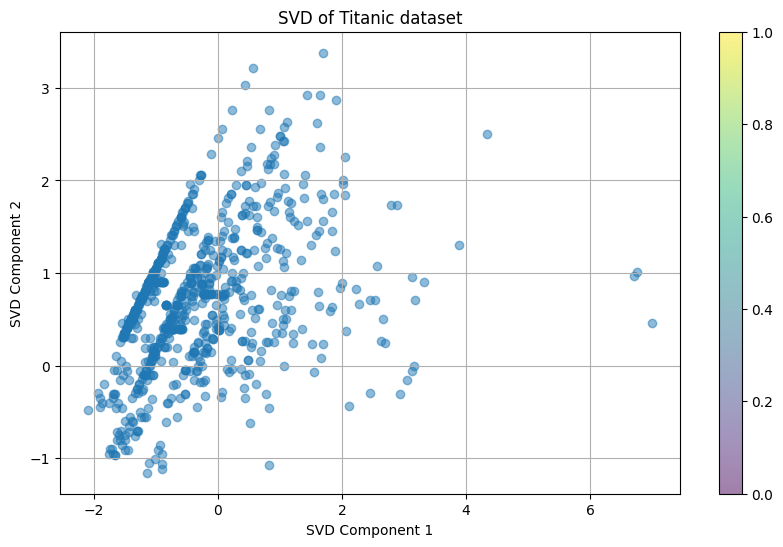

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(Y[:, 0], Y[:, 1], cmap='viridis', alpha=0.5) # plot the first two components
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('SVD of Titanic dataset')
plt.colorbar()
plt.grid(True)
plt.show()

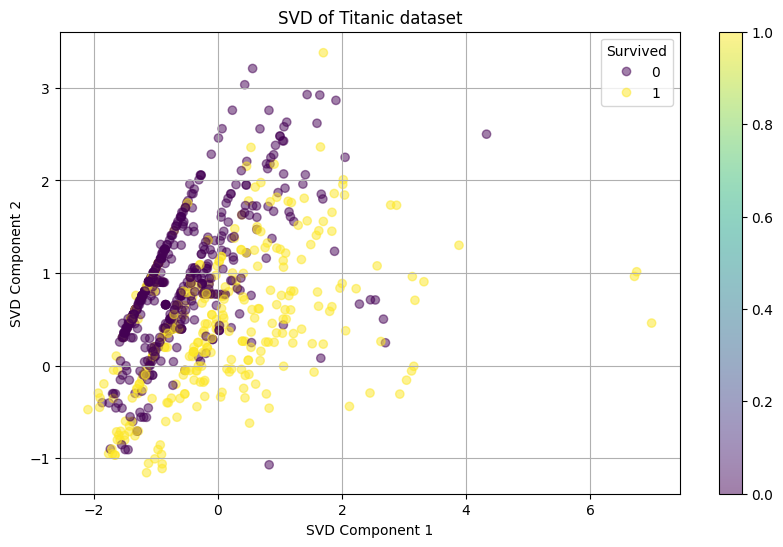

In [7]:
# Assuming "Survived" is the target variable
categories = titanic_df['survived'].values

plt.figure(figsize=(10, 6))
scatter = plt.scatter(Y[:, 0], Y[:, 1], c=categories, cmap='viridis', alpha=0.5) # plot the first two components
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('SVD of Titanic dataset')
plt.legend(*scatter.legend_elements(), title="Survived")
plt.colorbar()
plt.grid(True)
plt.show()

### **Image Compression and Face Recognition**

In [8]:
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_olivetti_faces

# Load dataset
faces = fetch_olivetti_faces(shuffle=True).data

# Compute PCA with eigenfaces
pca = PCA(n_components=50)
faces_reduced = pca.fit_transform(faces)

print("Eigenfaces shape:", faces_reduced.shape)

Eigenfaces shape: (400, 50)


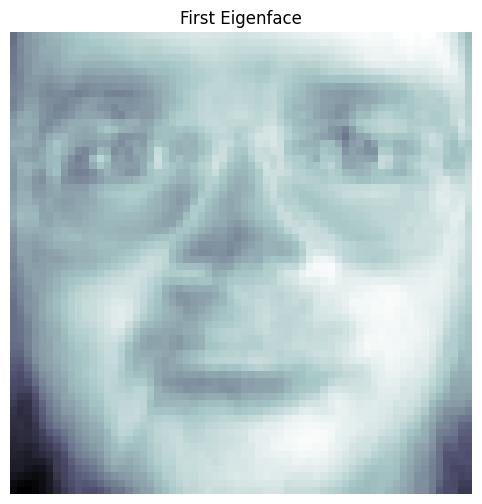

In [9]:
# show 1 eigenface
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(pca.components_[0].reshape(64, 64), cmap='bone')
plt.axis('off')
plt.title('First Eigenface')
plt.show()

----